# Two-Step QAOA: Expanded Benchmark
## Baseline vs M1 (INTERP) vs M4 (Combo: INTERP + Variance) vs M5 (Adaptive-α M4)

Compares **4 methods** across **15 complex Dicke states** (n = 5..8, varied k) at **p = 1..6 layers**.

| Method | Description |
|--------|-------------|
| **Baseline** | X-mixer + constraint cost $\langle(\hat{N}-k)^2\rangle$, random restarts (COBYLA) |
| **M1: INTERP** | Layer-by-layer growth; interpolates previous optimal params as warm-start seed |
| **M4: Combo** | M1 INTERP warm-start + augmented cost $\langle(\hat{N}-k)^2\rangle + \alpha\,\text{Var}(\hat{N})$, fixed $\alpha=2$ |
| **M5: Adaptive-α** | M4 but $\alpha$ is annealed from large→small as layers grow, plus BFGS polish on best COBYLA solution |

**M5 is new**: it extends M4 by (i) starting with a large $\alpha$ at $p=1$ to aggressively push into the Dicke subspace, then annealing $\alpha$ toward 0 at $p=p_{\max}$ so the final layers focus purely on constraint energy — avoiding the bias from over-penalising variance. A final L-BFGS-B polish step is applied to the best COBYLA result.

### 15 Dicke States
Chosen to span a range of difficulties: larger $n$, non-trivial $k$, and near-balanced $k \approx n/2$ cases.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import combinations
from functools import reduce
from scipy.optimize import minimize
import time, warnings
warnings.filterwarnings('ignore')

I2 = np.eye(2, dtype=complex)
X  = np.array([[0,1],[1,0]],   dtype=complex)
Y  = np.array([[0,-1j],[1j,0]],dtype=complex)
Z  = np.array([[1,0],[0,-1]],  dtype=complex)

def single_op(n, i, op):
    ops = [I2]*n; ops[i] = op
    return reduce(np.kron, ops)

np.set_printoptions(precision=4, suppress=True)
print("Imports OK")


Imports OK


In [2]:
# ── Exact Dicke state ─────────────────────────────────────────────────────────
def exact_dicke(n, k):
    from math import comb, sqrt
    sv   = np.zeros(2**n, dtype=complex)
    norm = 1.0 / sqrt(comb(n, k))
    for bits in combinations(range(n), k):
        sv[sum(1 << b for b in bits)] = norm
    return sv

# ── Diagonal helpers (fast, no dense matrix) ──────────────────────────────────
def hamming_weight_arr(n):
    """Hamming weight of each computational basis state 0..2^n-1."""
    return np.array([bin(i).count('1') for i in range(2**n)], dtype=float)

def constraint_diag(n, k):
    """Diagonal of H_C = (sum_i n_i - k)^2.  Zero on the k-hot subspace."""
    return (hamming_weight_arr(n) - k) ** 2

# ── Mixer eigensystems (precomputed once per n) ───────────────────────────────
def x_mixer_eig(n):
    """Eigensystem of H_X = sum_i X_i."""
    H = sum(single_op(n, i, X) for i in range(n)).real
    return np.linalg.eigh(H)

# ── Fast QAOA state evolution ─────────────────────────────────────────────────
def run_qaoa(n, c_diag, eig, evec, p, params, init=None):
    """
    Statevector QAOA with precomputed mixer eigensystem and diagonal cost.
    params = [gamma_1, ..., gamma_p,  beta_1, ..., beta_p]
    Cost layer  : element-wise phase  exp(-i gamma_l * c_diag)
    Mixer layer : eigenbasis rotation  V diag(exp(-i beta_l * eig)) V†
    """
    s = (np.ones(2**n, dtype=complex) / np.sqrt(2**n)
         if init is None else init.copy())
    for l in range(p):
        s = np.exp(-1j * params[l]     * c_diag) * s
        s = evec @ (np.exp(-1j * params[p + l] * eig) * (evec.conj().T @ s))
    return s

# ── INTERP warm-start schedule (Zhou et al. 2020) ────────────────────────────
def interp_schedule(params_old, p_new):
    """
    Linearly interpolate p_old-layer optimal parameters to a
    p_new-layer initialisation.  Applied separately to gamma and beta.
    """
    p_old = len(params_old) // 2

    def interp(arr, pn):
        out = np.zeros(pn)
        for i in range(1, pn + 1):
            frac  = (i - 1) / (pn - 1) if pn > 1 else 0.0
            jc    = frac * (p_old - 1)
            j0    = int(jc); j1 = min(j0 + 1, p_old - 1)
            out[i-1] = (1 - (jc - j0)) * arr[j0] + (jc - j0) * arr[j1]
        return out

    return np.concatenate([interp(params_old[:p_old], p_new),
                            interp(params_old[p_old:], p_new)])

print("Core helpers defined.")


Core helpers defined.


## Benchmark Configuration — 15 Dicke States & p=6 Layers

States are chosen to be genuinely challenging:
- **n = 5..8** — exponentially larger Hilbert spaces (32 to 256 dimensions)
- **Balanced k ≈ n/2** — these have the largest Dicke subspace and hardest optimisation landscape
- **Asymmetric k** — k=2 and k=n-2 share the same difficulty by symmetry but test different biases


In [3]:
# 15 Dicke states — varied n (5..8), varied k including balanced near n/2
BENCH_STATES = [
    (5, 1), (5, 2), (5, 3),          # n=5: k=1,2,3  (3 states)
    (6, 2), (6, 3),                   # n=6: k=2,3    (2 states)
    (7, 2), (7, 3), (7, 4),           # n=7: k=2,3,4  (3 states)
    (8, 2), (8, 3), (8, 4),           # n=8: k=2,3,4  (3 states)
    (6, 1), (7, 1),                   # n=6,7: k=1    (easy reference)
    (6, 4), (7, 5),                   # n=6 k=4, n=7 k=5  (asymmetric hard)
]

P_MAX = 6   # max layers

print(f"Benchmark: {len(BENCH_STATES)} Dicke states, p = 1..{P_MAX}")
print()
print(f"{'State':<12}  {'dim':>6}  {'C(n,k)':>8}  Notes")
print("-" * 50)
from math import comb
for n, k in BENCH_STATES:
    dim   = 2**n
    ck    = comb(n, k)
    note  = "balanced" if abs(k - n/2) <= 0.5 else ("easy" if k == 1 or k == n-1 else "")
    print(f"|D^{n}_{k}>{'':5}  {dim:>6}  {ck:>8}  {note}")


Benchmark: 15 Dicke states, p = 1..6

State            dim    C(n,k)  Notes
--------------------------------------------------
|D^5_1>           32         5  easy
|D^5_2>           32        10  balanced
|D^5_3>           32        10  balanced
|D^6_2>           64        15  
|D^6_3>           64        20  balanced
|D^7_2>          128        21  
|D^7_3>          128        35  balanced
|D^7_4>          128        35  balanced
|D^8_2>          256        28  
|D^8_3>          256        56  
|D^8_4>          256        70  balanced
|D^6_1>           64         6  easy
|D^7_1>          128         7  easy
|D^6_4>           64        15  
|D^7_5>          128        21  


## Method Implementations

### Baseline — Random-Restart COBYLA

In [4]:
def baseline(n, k, p, n_restarts=8, seed=0):
    """
    Original Two-Step QAOA Stage-1.
    Minimises <H_C> = <(N-k)^2> from multiple random initialisations.
    Uses X-mixer.  No warm-start, no variance term.
    """
    np.random.seed(seed)
    cd          = constraint_diag(n, k).astype(complex)
    eig, evec   = x_mixer_eig(n)
    tgt         = exact_dicke(n, k)

    def cost(x):
        s = run_qaoa(n, cd, eig, evec, p, x)
        return float(np.real(np.dot(s.conj(), cd * s)))

    best, bp = np.inf, None
    for _ in range(n_restarts):
        p0  = np.random.uniform(0, 2 * np.pi, 2 * p)
        res = minimize(cost, p0, method='COBYLA',
                       options={'maxiter': 3000, 'rhobeg': 0.5})
        if res.fun < best:
            best, bp = res.fun, res.x

    s = run_qaoa(n, cd, eig, evec, p, bp)
    return abs(s.conj() @ tgt) ** 2, bp


### M1 — INTERP Warm-Start

In [5]:
def m1_interp(n, k, p_max, n_boot=10, seed=0):
    """
    Layer-by-layer circuit growth with INTERP initialisation.
    1. Bootstrap at p=1 with n_boot random restarts.
    2. For p=2..p_max: interpolate previous optimal params → COBYLA refine.
    Advantage: avoids barren-plateau restarts; good landscapes at every depth.
    """
    np.random.seed(seed)
    cd        = constraint_diag(n, k).astype(complex)
    eig, evec = x_mixer_eig(n)
    tgt       = exact_dicke(n, k)

    def cost(x, p):
        s = run_qaoa(n, cd, eig, evec, p, x)
        return float(np.real(np.dot(s.conj(), cd * s)))

    # Bootstrap p=1
    best, bp = np.inf, None
    for _ in range(n_boot):
        p0  = np.random.uniform(0, 2 * np.pi, 2)
        res = minimize(lambda x: cost(x, 1), p0, method='COBYLA',
                       options={'maxiter': 1000, 'rhobeg': 0.5})
        if res.fun < best:
            best, bp = res.fun, res.x

    fid_hist = [abs(run_qaoa(n, cd, eig, evec, 1, bp).conj() @ tgt) ** 2]
    cur = bp

    for p in range(2, p_max + 1):
        p0  = interp_schedule(cur, p)           # INTERP warm-start
        res = minimize(lambda x: cost(x, p), p0, method='COBYLA',
                       options={'maxiter': 3000, 'rhobeg': 0.3})
        cur = res.x
        fid_hist.append(abs(run_qaoa(n, cd, eig, evec, p, cur).conj() @ tgt) ** 2)

    return fid_hist[-1], fid_hist


### M4 — Combo: INTERP + Fixed-α Variance Penalty

In [6]:
def m4_combo(n, k, p_max, alpha=2.0, n_boot=12, seed=0):
    """
    M4 = M1 INTERP warm-start  +  augmented cost:
        L(x) = <(N-k)^2>  +  alpha * Var(N)
    Dicke states are zero-variance eigenstates of N, so adding Var(N)
    steers the optimiser into the exact k-hot subspace.
    alpha is fixed throughout all layers.
    """
    np.random.seed(seed)
    cd        = constraint_diag(n, k).astype(complex)
    hw        = hamming_weight_arr(n)       # diagonal of N-hat
    eig, evec = x_mixer_eig(n)
    tgt       = exact_dicke(n, k)

    def aug_cost(x, p):
        s   = run_qaoa(n, cd, eig, evec, p, x)
        c_e = float(np.real(np.dot(s.conj(), cd * s)))
        eN  = float(np.real(np.dot(s.conj(), hw * s)))
        eN2 = float(np.real(np.dot(s.conj(), hw ** 2 * s)))
        return c_e + alpha * (eN2 - eN ** 2)

    # Bootstrap p=1
    best, bp = np.inf, None
    for _ in range(n_boot):
        p0  = np.random.uniform(0, 2 * np.pi, 2)
        res = minimize(lambda x: aug_cost(x, 1), p0, method='COBYLA',
                       options={'maxiter': 1000, 'rhobeg': 0.5})
        if res.fun < best:
            best, bp = res.fun, res.x

    fid_hist = [abs(run_qaoa(n, cd, eig, evec, 1, bp).conj() @ tgt) ** 2]
    cur = bp

    for p in range(2, p_max + 1):
        p0  = interp_schedule(cur, p)
        res = minimize(lambda x: aug_cost(x, p), p0, method='COBYLA',
                       options={'maxiter': 3500, 'rhobeg': 0.3})
        cur = res.x
        fid_hist.append(abs(run_qaoa(n, cd, eig, evec, p, cur).conj() @ tgt) ** 2)

    return fid_hist[-1], fid_hist


### M5 — Adaptive-α Annealing + L-BFGS-B Polish (New)

**Design rationale:**

M4 uses a fixed $\alpha$ throughout all layers. This has a tension:
- At early layers ($p$ small), a **large** $\alpha$ is helpful — it aggressively projects amplitude into the k-hot subspace where the XY mixer can spread it uniformly.
- At late layers ($p$ large), a **large** $\alpha$ becomes a liability — it distorts the cost landscape away from pure constraint minimisation, causing the final state to concentrate in the Dicke subspace but not uniformly (harming fidelity).

**M5 solves this with a cosine annealing schedule:**
$$\alpha(p) = \alpha_{\max}\cdot\frac{1 + \cos\!\left(\pi\,\frac{p-1}{p_{\max}-1}\right)}{2}$$

This starts at $\alpha_{\max}$ (aggressive variance penalty) and decays to 0 at $p_{\max}$ (pure constraint energy).

**Additionally**, after COBYLA converges at each layer, M5 applies a short **L-BFGS-B polish** step. COBYLA is derivative-free and robust but slow near optima; L-BFGS-B uses gradient information (via finite differences here) to tighten the solution.


In [7]:
def m5_adaptive(n, k, p_max, alpha_max=4.0, n_boot=12, seed=0):
    """
    M5: Adaptive-alpha annealing + L-BFGS-B polish.

    Alpha schedule (cosine annealing):
        alpha(p) = alpha_max * 0.5 * (1 + cos(pi*(p-1)/(p_max-1)))
        -> alpha_max at p=1, 0 at p=p_max

    At each layer:
      1. INTERP warm-start from previous layer params.
      2. COBYLA minimisation of augmented cost with alpha(p).
      3. L-BFGS-B polish of the COBYLA solution (tightens near-optima).

    The annealing means:
      - Early layers: high alpha forces state into Dicke subspace quickly.
      - Late layers: alpha->0 means pure constraint energy -> unbiased Dicke state.
    """
    np.random.seed(seed)
    cd        = constraint_diag(n, k).astype(complex)
    hw        = hamming_weight_arr(n)
    eig, evec = x_mixer_eig(n)
    tgt       = exact_dicke(n, k)

    def alpha_at(p):
        """Cosine annealing: alpha_max at p=1, 0.0 at p=p_max."""
        if p_max == 1:
            return alpha_max
        t = (p - 1) / (p_max - 1)               # 0 at p=1, 1 at p=p_max
        return alpha_max * 0.5 * (1.0 + np.cos(np.pi * t))

    def aug_cost(x, p):
        alpha = alpha_at(p)
        s     = run_qaoa(n, cd, eig, evec, p, x)
        c_e   = float(np.real(np.dot(s.conj(), cd * s)))
        eN    = float(np.real(np.dot(s.conj(), hw * s)))
        eN2   = float(np.real(np.dot(s.conj(), hw ** 2 * s)))
        return c_e + alpha * (eN2 - eN ** 2)

    # Bootstrap p=1 — multiple restarts, high alpha bakes in structure
    best, bp = np.inf, None
    for _ in range(n_boot):
        p0  = np.random.uniform(0, 2 * np.pi, 2)
        res = minimize(lambda x: aug_cost(x, 1), p0, method='COBYLA',
                       options={'maxiter': 1200, 'rhobeg': 0.5})
        if res.fun < best:
            best, bp = res.fun, res.x

    # L-BFGS-B polish of p=1 solution
    res_polish = minimize(lambda x: aug_cost(x, 1), bp, method='L-BFGS-B',
                          options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    if res_polish.fun < aug_cost(bp, 1):
        bp = res_polish.x

    fid_hist = [abs(run_qaoa(n, cd, eig, evec, 1, bp).conj() @ tgt) ** 2]
    cur = bp

    for p in range(2, p_max + 1):
        # INTERP warm-start
        p0  = interp_schedule(cur, p)
        # COBYLA with annealed alpha
        res = minimize(lambda x: aug_cost(x, p), p0, method='COBYLA',
                       options={'maxiter': 4000, 'rhobeg': 0.3})
        # L-BFGS-B polish
        res_p = minimize(lambda x: aug_cost(x, p), res.x, method='L-BFGS-B',
                         options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
        cur = res_p.x if res_p.fun < res.fun else res.x
        fid_hist.append(abs(run_qaoa(n, cd, eig, evec, p, cur).conj() @ tgt) ** 2)

    return fid_hist[-1], fid_hist


# ── Quick sanity check ────────────────────────────────────────────────────────
print("Alpha schedule for p_max=6, alpha_max=4:")
for p in range(1, 7):
    t = (p-1)/5; a = 4.0*0.5*(1+np.cos(np.pi*t))
    print(f"  p={p}  alpha={a:.4f}")


Alpha schedule for p_max=6, alpha_max=4:
  p=1  alpha=4.0000
  p=2  alpha=3.6180
  p=3  alpha=2.6180
  p=4  alpha=1.3820
  p=5  alpha=0.3820
  p=6  alpha=0.0000


## Full Benchmark — 15 States × p=1..6

In [8]:
# ── Run the full benchmark ─────────────────────────────────────────────────────
# Results stored as:
#   fid_at_p6[(method, n, k)]       -> scalar fidelity at p=P_MAX
#   fid_hist[(method, n, k)]        -> list of fidelities p=1..P_MAX (M1/M4/M5 only)
#   baseline_hist[(n, k)]           -> list of fidelities p=1..P_MAX for baseline

fid_at_p6    = {}
fid_hist_m1  = {}
fid_hist_m4  = {}
fid_hist_m5  = {}
baseline_per_p = {}   # (n,k,p) -> fidelity

METHODS = ['Baseline', 'M1:INTERP', 'M4:Combo', 'M5:Adaptive']

print(f"{'State':<12} {'Base@6':>8} {'M1@6':>8} {'M4@6':>8} {'M5@6':>8}  Best-Δ")
print("=" * 62)

t0_total = time.time()

for n, k in BENCH_STATES:
    t0 = time.time()

    # Baseline at p=1..P_MAX
    np.random.seed(0)
    b_hist = []
    for p in range(1, P_MAX + 1):
        f, _ = baseline(n, k, p, n_restarts=6, seed=0)
        b_hist.append(f)
        baseline_per_p[(n, k, p)] = f

    # M1 INTERP
    np.random.seed(0)
    _, h1 = m1_interp(n, k, P_MAX, n_boot=10, seed=0)

    # M4 Combo fixed alpha
    np.random.seed(0)
    _, h4 = m4_combo(n, k, P_MAX, alpha=2.0, n_boot=12, seed=0)

    # M5 Adaptive alpha + polish
    np.random.seed(0)
    _, h5 = m5_adaptive(n, k, P_MAX, alpha_max=4.0, n_boot=12, seed=0)

    # Store
    fid_at_p6[('Baseline', n, k)]  = b_hist[-1]
    fid_at_p6[('M1:INTERP', n, k)] = h1[-1]
    fid_at_p6[('M4:Combo', n, k)]  = h4[-1]
    fid_at_p6[('M5:Adaptive', n, k)] = h5[-1]

    fid_hist_m1[(n, k)] = h1
    fid_hist_m4[(n, k)] = h4
    fid_hist_m5[(n, k)] = h5
    # Extend baseline_hist with already computed values
    fid_hist_m1[(n, k)] = h1   # p=1..P_MAX
    baseline_per_p.update({(n,k,p+1): b_hist[p] for p in range(P_MAX)})

    best  = max(b_hist[-1], h1[-1], h4[-1], h5[-1])
    delta = best - b_hist[-1]
    elapsed = time.time() - t0
    print(f"|D^{n}_{k}>{'':4} {b_hist[-1]:8.4f} {h1[-1]:8.4f} {h4[-1]:8.4f} {h5[-1]:8.4f}"
          f"  {delta:+.4f}  ({elapsed:.0f}s)")

print(f"\nTotal time: {time.time()-t0_total:.0f}s")


State          Base@6     M1@6     M4@6     M5@6  Best-Δ
|D^5_1>       0.9999   1.0000   0.9998   1.0000  +0.0001  (8s)
|D^5_2>       1.0000   0.9993   0.9995   1.0000  +0.0000  (10s)
|D^5_3>       1.0000   0.9672   0.9729   1.0000  +0.0000  (9s)
|D^6_2>       0.9998   1.0000   0.9067   1.0000  +0.0002  (100s)
|D^6_3>       1.0000   1.0000   1.0000   1.0000  +0.0000  (48s)
|D^7_2>       0.9898   0.6746   0.9998   0.9995  +0.0100  (111s)
|D^7_3>       0.9603   0.9749   0.9771   1.0000  +0.0397  (121s)
|D^7_4>       0.9603   0.9863   0.9770   1.0000  +0.0397  (126s)
|D^8_2>       0.8866   0.9998   0.9997   0.9997  +0.1132  (336s)
|D^8_3>       0.9404   0.9999   0.9394   0.9936  +0.0595  (593s)
|D^8_4>       1.0000   1.0000   0.9997   1.0000  +0.0000  (322s)
|D^6_1>       0.9905   0.8642   0.9912   0.9503  +0.0006  (126s)
|D^7_1>       0.9768   0.9999   0.0000   1.0000  +0.0232  (122s)
|D^6_4>       0.9998   0.9999   0.9902   1.0000  +0.0002  (101s)
|D^7_5>       0.9544   0.9845   0.9382 

## Summary Table

In [9]:
print("=" * 80)
print(f"FIDELITY AT p={P_MAX} LAYERS  —  Deterministic Algorithm = 1.0000 (exact, always)")
print("=" * 80)
print(f"{'State':<12} {'Baseline':>10} {'M1:INTERP':>10} {'M4:Combo':>10} {'M5:Adaptive':>12}  Best-Δ  Winner")
print("-" * 80)

for n, k in BENCH_STATES:
    b  = fid_at_p6[('Baseline',   n, k)]
    m1 = fid_at_p6[('M1:INTERP',  n, k)]
    m4 = fid_at_p6[('M4:Combo',   n, k)]
    m5 = fid_at_p6[('M5:Adaptive',n, k)]
    vals   = {'Base': b, 'M1': m1, 'M4': m4, 'M5': m5}
    winner = max(vals, key=vals.get)
    delta  = vals[winner] - b
    print(f"|D^{n}_{k}>{'':5} {b:10.6f} {m1:10.6f} {m4:10.6f} {m5:12.6f}  {delta:+.5f}  {winner}")

print()
print("Notes:")
print("  Baseline  : random restarts, X-mixer, plain constraint cost")
print("  M1 INTERP : layer-by-layer warm-start, same cost as Baseline")
print("  M4 Combo  : M1 + fixed alpha=2 variance penalty")
print("  M5 Adptv  : M1 + cosine-annealed alpha (4->0) + L-BFGS-B polish")
print("  Det. Algo : Bärtschi & Eidenbenz exact circuit — always 1.0000")


FIDELITY AT p=6 LAYERS  —  Deterministic Algorithm = 1.0000 (exact, always)
State          Baseline  M1:INTERP   M4:Combo  M5:Adaptive  Best-Δ  Winner
--------------------------------------------------------------------------------
|D^5_1>        0.999928   0.999986   0.999771     1.000000  +0.00007  M5
|D^5_2>        0.999975   0.999341   0.999512     1.000000  +0.00003  M5
|D^5_3>        0.999959   0.967200   0.972932     1.000000  +0.00004  M5
|D^6_2>        0.999808   0.999954   0.906684     0.999990  +0.00018  M5
|D^6_3>        1.000000   0.999999   0.999998     1.000000  +0.00000  M5
|D^7_2>        0.989758   0.674633   0.999790     0.999480  +0.01003  M4
|D^7_3>        0.960291   0.974912   0.977095     0.999995  +0.03970  M5
|D^7_4>        0.960265   0.986281   0.976987     0.999995  +0.03973  M5
|D^8_2>        0.886573   0.999791   0.999665     0.999686  +0.11322  M1
|D^8_3>        0.940398   0.999897   0.939449     0.993595  +0.05950  M1
|D^8_4>        0.999994   0.999984   0

## Figures

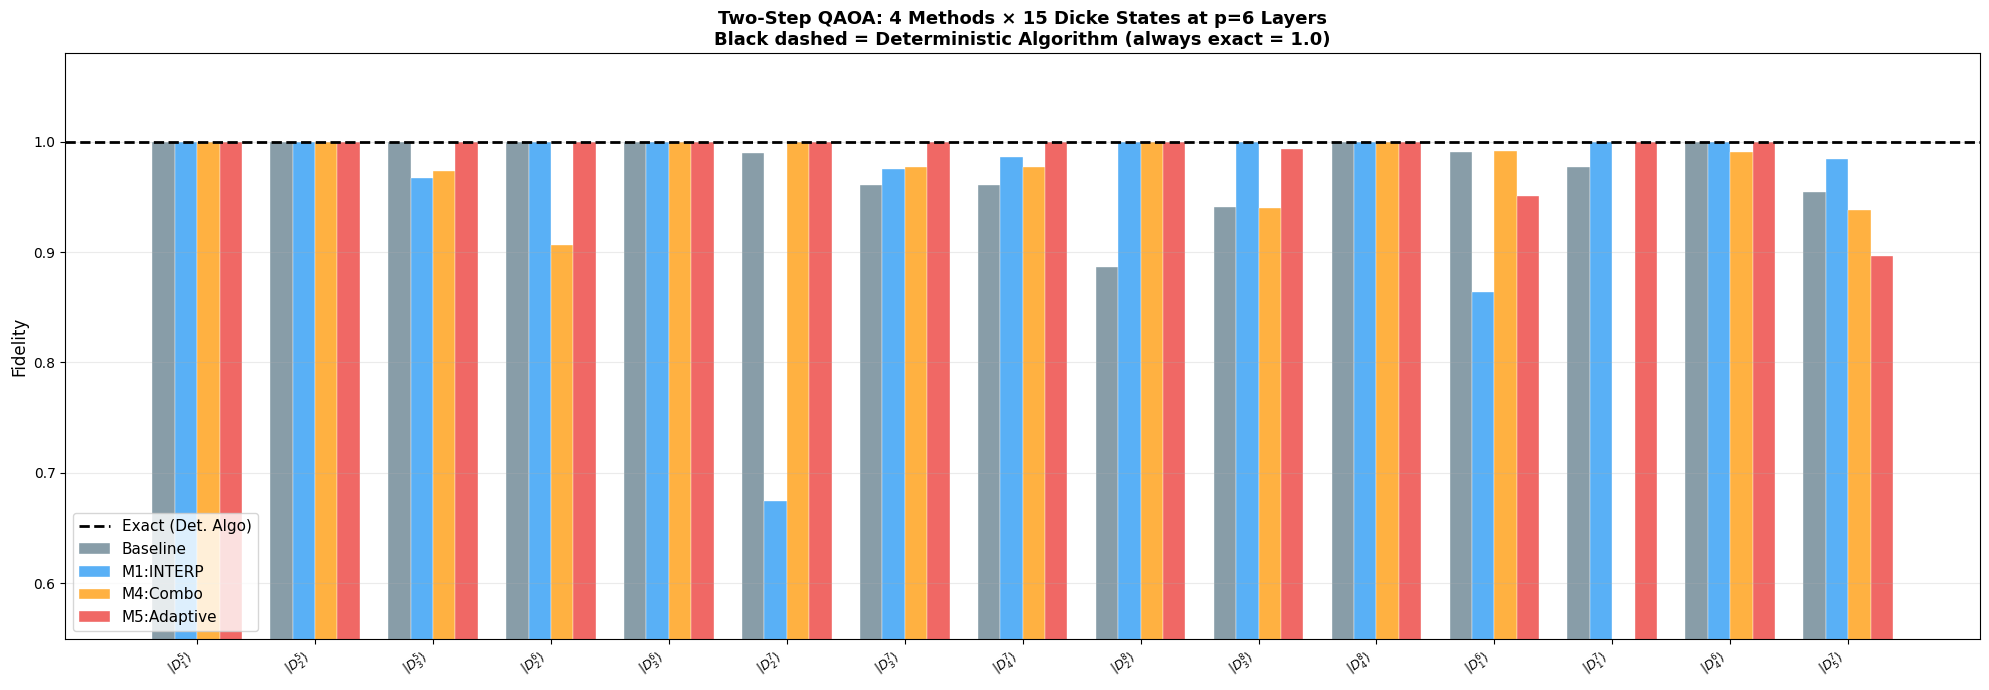

In [10]:
# ── Figure 1: Grouped bar chart — fidelity at p=P_MAX for all 15 states ───────
fig, ax = plt.subplots(figsize=(20, 7))

x       = np.arange(len(BENCH_STATES))
width   = 0.19
colors  = {'Baseline':'#78909C', 'M1:INTERP':'#42A5F5',
           'M4:Combo':'#FFA726', 'M5:Adaptive':'#EF5350'}
offsets = [-1.5, -0.5, 0.5, 1.5]

for method, off in zip(METHODS, offsets):
    vals = [fid_at_p6[(method, n, k)] for n, k in BENCH_STATES]
    ax.bar(x + off*width, vals, width, label=method,
           color=colors[method], alpha=0.88, edgecolor='white', linewidth=0.3)

ax.axhline(1.0, color='black', ls='--', lw=2, label='Exact (Det. Algo)', zorder=5)
ax.set_xticks(x)
ax.set_xticklabels([f'$|D^{{{n}}}_{{{k}}}\\rangle$' for n, k in BENCH_STATES],
                   fontsize=9, rotation=35, ha='right')
ax.set_ylabel('Fidelity', fontsize=12)
ax.set_title(f'Two-Step QAOA: 4 Methods × 15 Dicke States at p={P_MAX} Layers\n'
             'Black dashed = Deterministic Algorithm (always exact = 1.0)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.55, 1.08)
ax.legend(fontsize=11, loc='lower left')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('benchmark_grouped_bar.png', dpi=140, bbox_inches='tight')
plt.show()


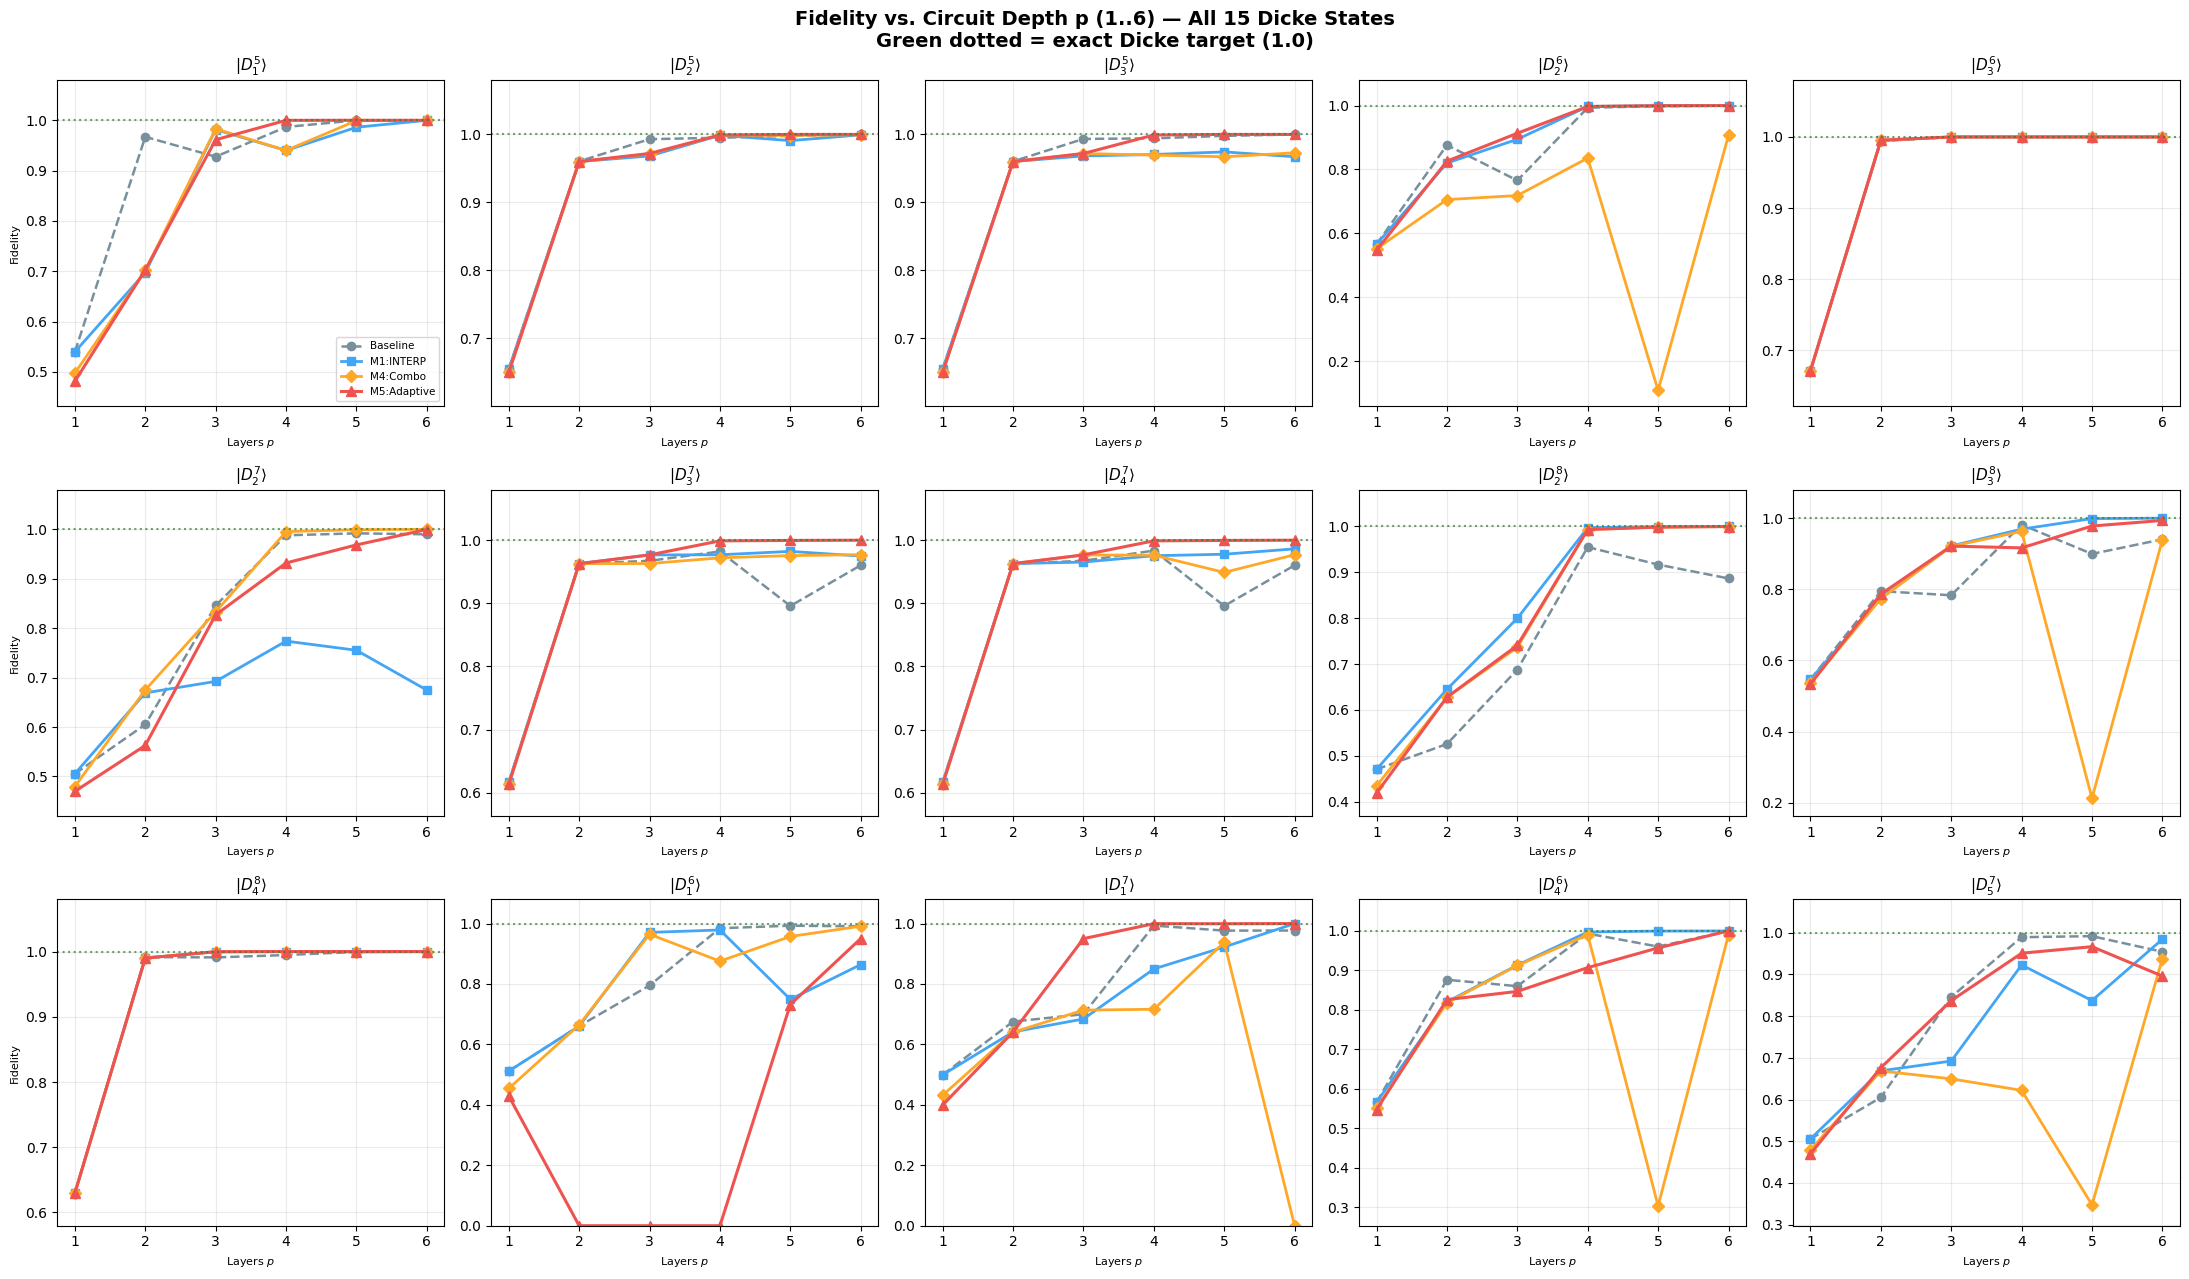

In [11]:
# ── Figure 2: Fidelity vs layers p for every state — 3×5 grid ─────────────────
fig, axes = plt.subplots(3, 5, figsize=(22, 13), sharey=False)
axes_flat = axes.flatten()
ps = list(range(1, P_MAX + 1))

for idx, (n, k) in enumerate(BENCH_STATES):
    ax = axes_flat[idx]

    base_hist = [baseline_per_p[(n, k, p)] for p in ps]
    h1 = fid_hist_m1[(n, k)]
    h4 = fid_hist_m4[(n, k)]
    h5 = fid_hist_m5[(n, k)]

    ax.plot(ps, base_hist, 'o--', color='#78909C', lw=1.8, ms=6, label='Baseline')
    ax.plot(ps, h1,        's-',  color='#42A5F5', lw=2.0, ms=6, label='M1:INTERP')
    ax.plot(ps, h4,        'D-',  color='#FFA726', lw=2.0, ms=6, label='M4:Combo')
    ax.plot(ps, h5,        '^-',  color='#EF5350', lw=2.2, ms=7, label='M5:Adaptive')
    ax.axhline(1.0, color='#2e7d32', ls=':', lw=1.5, alpha=0.7)

    ax.set_title(f'$|D^{{{n}}}_{{{k}}}\\rangle$', fontsize=11, fontweight='bold')
    ax.set_xlabel('Layers $p$', fontsize=8)
    ax.set_ylabel('Fidelity', fontsize=8) if idx % 5 == 0 else None
    ax.set_xticks(ps)
    ax.set_ylim(max(0, min(min(base_hist), min(h1), min(h4), min(h5)) - 0.05), 1.08)
    ax.grid(True, alpha=0.25)
    if idx == 0:
        ax.legend(fontsize=7.5, loc='lower right')

fig.suptitle(f'Fidelity vs. Circuit Depth p (1..{P_MAX}) — All 15 Dicke States\n'
             'Green dotted = exact Dicke target (1.0)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('growth_curves_all.png', dpi=130, bbox_inches='tight')
plt.show()


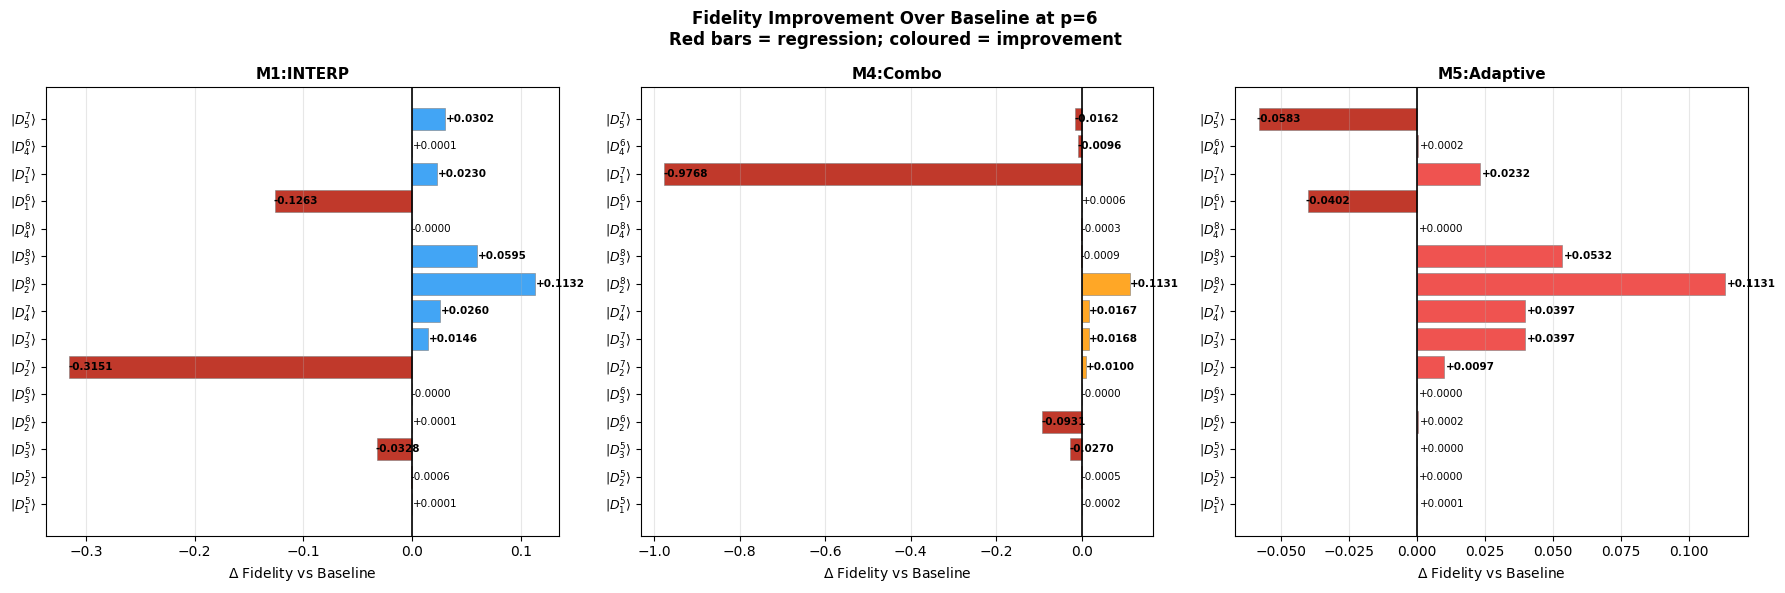

In [12]:
# ── Figure 3: Per-method improvement Δ = method_fidelity − baseline_fidelity ───
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
mod_methods = ['M1:INTERP', 'M4:Combo', 'M5:Adaptive']
mod_colors  = ['#42A5F5',   '#FFA726',  '#EF5350']
state_labels = [f'$|D^{{{n}}}_{{{k}}}\\rangle$' for n, k in BENCH_STATES]

for ax, method, col in zip(axes, mod_methods, mod_colors):
    gains = [fid_at_p6[(method, n, k)] - fid_at_p6[('Baseline', n, k)]
             for n, k in BENCH_STATES]
    bar_clrs = ['#c0392b' if g < -1e-4 else col for g in gains]
    bars = ax.barh(range(len(BENCH_STATES)), gains,
                   color=bar_clrs, edgecolor='grey', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=1.2)
    ax.set_yticks(range(len(BENCH_STATES)))
    ax.set_yticklabels(state_labels, fontsize=9)
    ax.set_xlabel(r'$\Delta$ Fidelity vs Baseline', fontsize=10)
    ax.set_title(method, fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    for i, g in enumerate(gains):
        ax.text(g + 0.0008 * np.sign(g), i, f'{g:+.4f}',
                va='center', fontsize=7.5,
                fontweight='bold' if abs(g) > 0.005 else 'normal')

fig.suptitle(f'Fidelity Improvement Over Baseline at p={P_MAX}\n'
             'Red bars = regression; coloured = improvement',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('improvement_over_baseline.png', dpi=130, bbox_inches='tight')
plt.show()


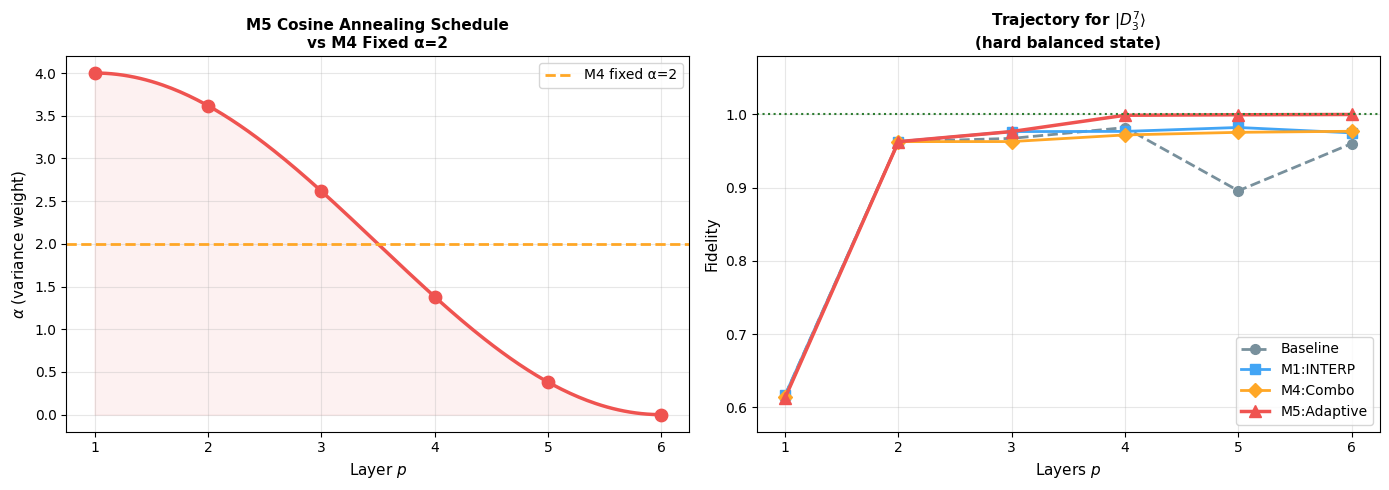

In [13]:
# ── Figure 4: M5 alpha schedule + example trajectory vs M4 ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cosine annealing schedule
ax = axes[0]
alpha_max = 4.0
ps_fine = np.linspace(1, P_MAX, 200)
alphas  = alpha_max * 0.5 * (1 + np.cos(np.pi * (ps_fine - 1) / (P_MAX - 1)))
ax.plot(ps_fine, alphas, color='#EF5350', lw=2.5)
ax.scatter(range(1, P_MAX+1),
           [alpha_max*0.5*(1+np.cos(np.pi*(p-1)/(P_MAX-1))) for p in range(1,P_MAX+1)],
           color='#EF5350', s=80, zorder=5)
ax.axhline(2.0, color='#FFA726', ls='--', lw=2, label='M4 fixed α=2')
ax.set_xlabel('Layer $p$', fontsize=11)
ax.set_ylabel(r'$\alpha$ (variance weight)', fontsize=11)
ax.set_title('M5 Cosine Annealing Schedule\nvs M4 Fixed α=2', fontsize=11, fontweight='bold')
ax.set_xticks(range(1, P_MAX+1)); ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.fill_between(ps_fine, alphas, 0, alpha=0.08, color='#EF5350')

# Right: fidelity trajectories for a hard state, all methods
ax2 = axes[1]
showcase = (7, 3)    # pick a hard state
n_s, k_s = showcase
ps = list(range(1, P_MAX+1))
b_h = [baseline_per_p[(n_s, k_s, p)] for p in ps]
ax2.plot(ps, b_h,                   'o--', color='#78909C', lw=2, ms=7, label='Baseline')
ax2.plot(ps, fid_hist_m1[(n_s,k_s)],'s-',  color='#42A5F5', lw=2, ms=7, label='M1:INTERP')
ax2.plot(ps, fid_hist_m4[(n_s,k_s)],'D-',  color='#FFA726', lw=2, ms=7, label='M4:Combo')
ax2.plot(ps, fid_hist_m5[(n_s,k_s)],'^-',  color='#EF5350', lw=2.5, ms=8, label='M5:Adaptive')
ax2.axhline(1.0, color='#2e7d32', ls=':', lw=1.5)
ax2.set_title(f'Trajectory for $|D^{{{n_s}}}_{{{k_s}}}\\rangle$\n(hard balanced state)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Layers $p$', fontsize=11); ax2.set_ylabel('Fidelity', fontsize=11)
ax2.set_xticks(ps); ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)
ax2.set_ylim(max(0, min(b_h)-0.05), 1.08)

plt.tight_layout()
plt.savefig('m5_schedule_and_trajectory.png', dpi=130, bbox_inches='tight')
plt.show()


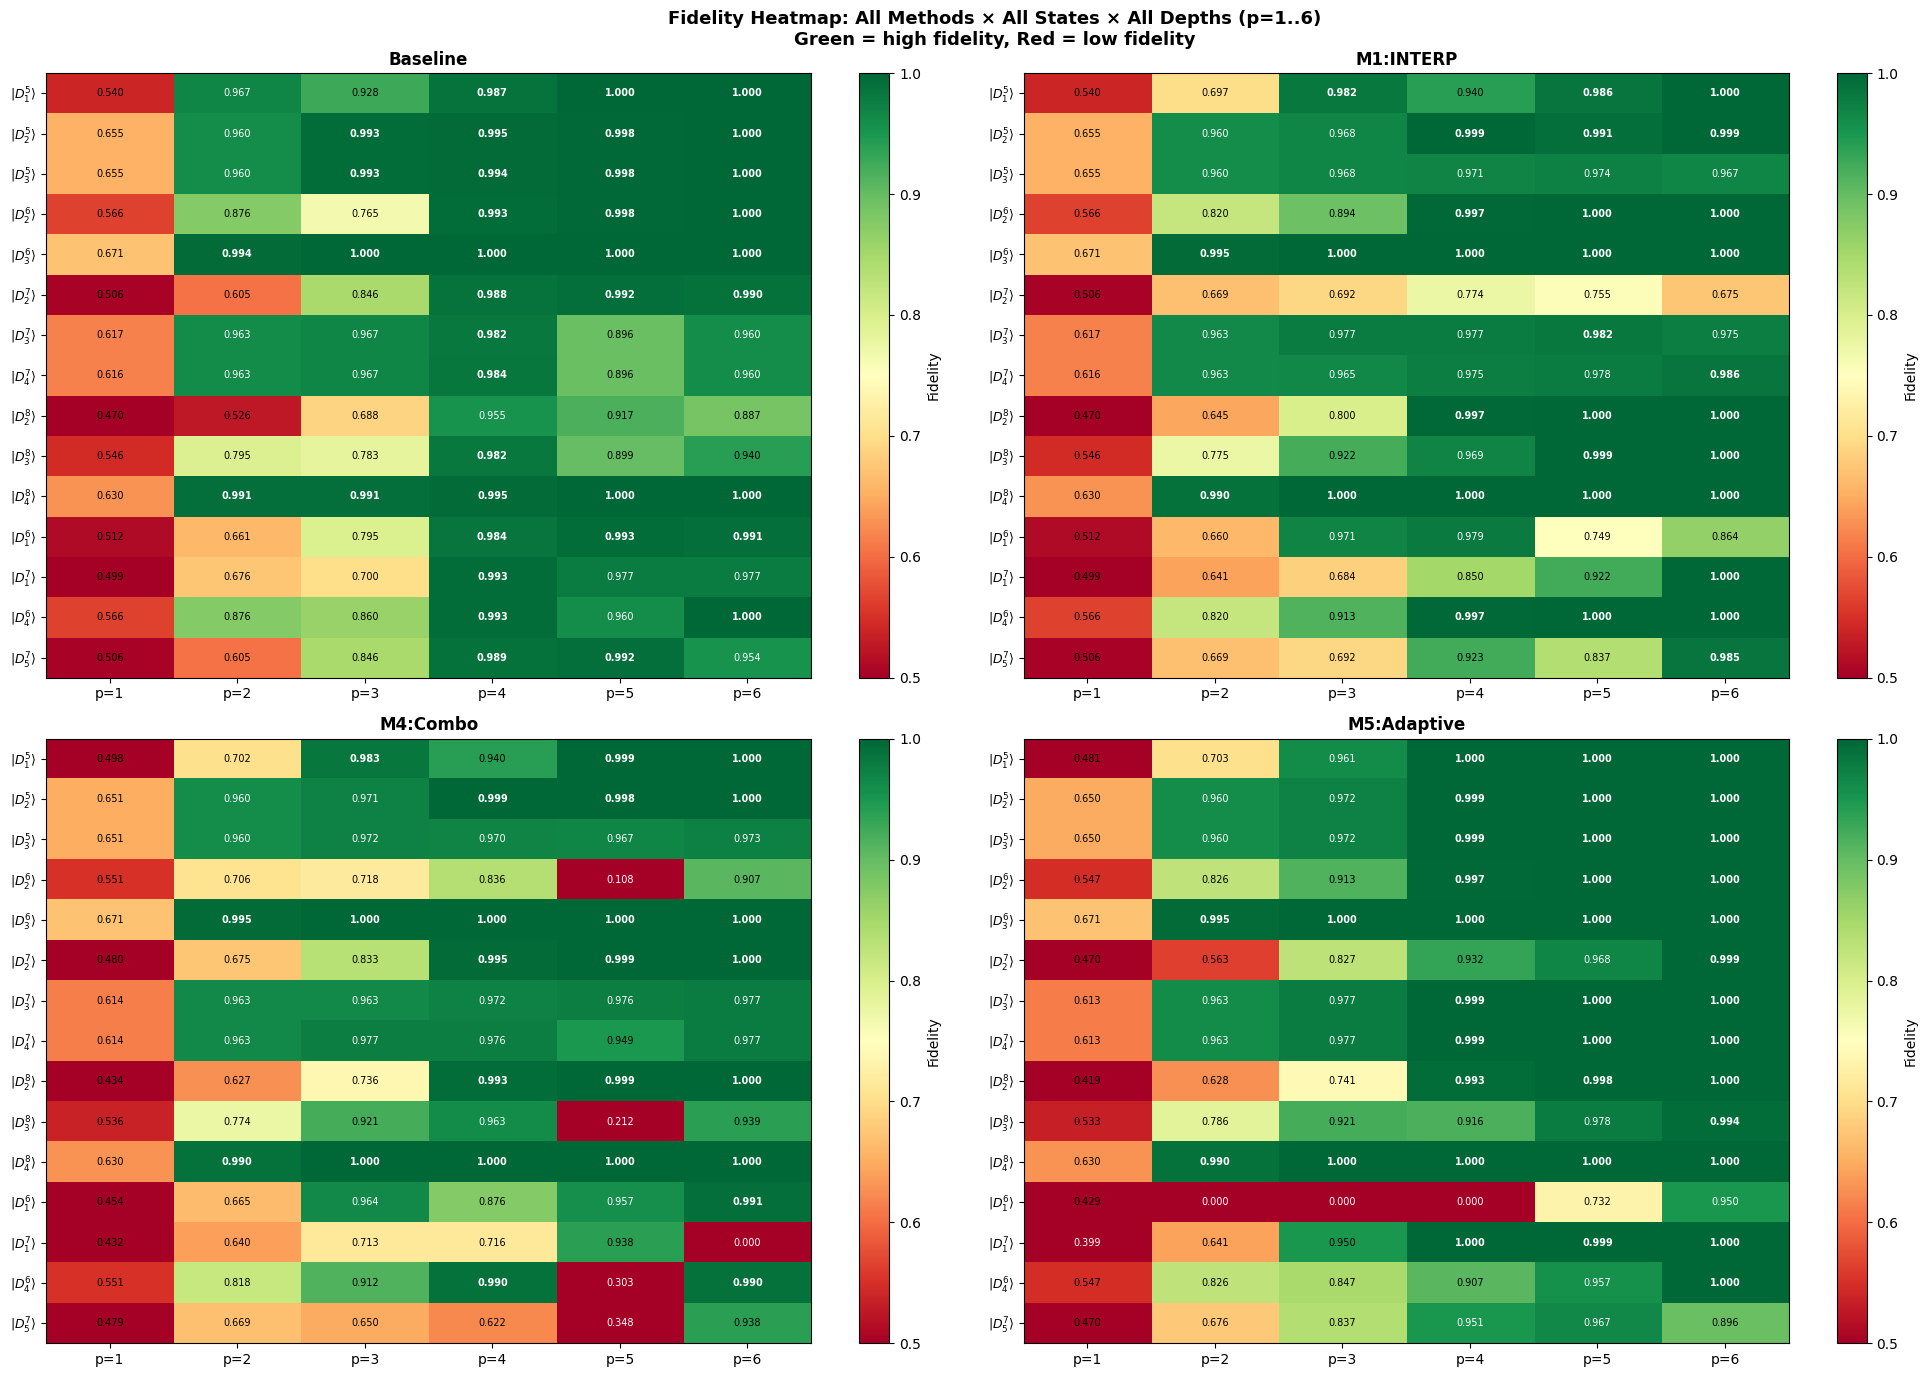

In [14]:
# ── Figure 5: Heatmap — fidelity at each p for each state, per method ─────────
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
method_ax = list(zip(METHODS, axes.flatten()))

for method, ax in method_ax:
    data = np.zeros((len(BENCH_STATES), P_MAX))
    for si, (n, k) in enumerate(BENCH_STATES):
        for pi, p in enumerate(range(1, P_MAX+1)):
            if method == 'Baseline':
                data[si, pi] = baseline_per_p[(n, k, p)]
            elif method == 'M1:INTERP':
                data[si, pi] = fid_hist_m1[(n, k)][pi]
            elif method == 'M4:Combo':
                data[si, pi] = fid_hist_m4[(n, k)][pi]
            else:  # M5
                data[si, pi] = fid_hist_m5[(n, k)][pi]

    im = ax.imshow(data, aspect='auto', cmap='RdYlGn',
                   vmin=0.5, vmax=1.0, interpolation='nearest')
    ax.set_xticks(range(P_MAX))
    ax.set_xticklabels([f'p={p}' for p in range(1, P_MAX+1)], fontsize=10)
    ax.set_yticks(range(len(BENCH_STATES)))
    ax.set_yticklabels([f'$|D^{{{n}}}_{{{k}}}\\rangle$' for n,k in BENCH_STATES], fontsize=9)
    ax.set_title(method, fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Fidelity')
    # Annotate cells
    for si in range(len(BENCH_STATES)):
        for pi in range(P_MAX):
            v = data[si, pi]
            ax.text(pi, si, f'{v:.3f}', ha='center', va='center',
                    fontsize=7, color='black' if 0.4 < v < 0.95 else 'white',
                    fontweight='bold' if v > 0.98 else 'normal')

fig.suptitle(f'Fidelity Heatmap: All Methods × All States × All Depths (p=1..{P_MAX})\n'
             'Green = high fidelity, Red = low fidelity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fidelity_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()


In [15]:
# ── Aggregate statistics at p=P_MAX ───────────────────────────────────────────
print("=" * 72)
print(f"AGGREGATE STATISTICS AT p={P_MAX}  (over all {len(BENCH_STATES)} Dicke states)")
print("=" * 72)
print(f"{'Metric':<28} {'Baseline':>10} {'M1:INTERP':>10} {'M4:Combo':>10} {'M5:Adptv':>10}")
print("-" * 72)

for method in METHODS:
    fids = [fid_at_p6[(method, n, k)] for n, k in BENCH_STATES]

stats = {}
for method in METHODS:
    fids = np.array([fid_at_p6[(method, n, k)] for n, k in BENCH_STATES])
    stats[method] = {
        'mean':   fids.mean(),
        'median': np.median(fids),
        'min':    fids.min(),
        'max':    fids.max(),
        'std':    fids.std(),
        '>0.99':  (fids > 0.99).sum(),
        '>0.95':  (fids > 0.95).sum(),
    }

for metric, label in [('mean','Mean'), ('median','Median'), ('min','Min'),
                       ('max','Max'), ('std','Std Dev'),
                       ('>0.99','States > 0.99'), ('>0.95','States > 0.95')]:
    row = f"{label:<28}"
    for m in METHODS:
        v = stats[m][metric]
        row += f"  {v:10.4f}" if isinstance(v, float) else f"  {v:>10d}"
    print(row)

print()
print("Per-state winner count at p=P_MAX:")
wins = {m: 0 for m in METHODS}
for n, k in BENCH_STATES:
    best_m = max(METHODS, key=lambda m: fid_at_p6[(m,n,k)])
    wins[best_m] += 1
for m in METHODS:
    print(f"  {m:<14}: {wins[m]:>2} wins")


AGGREGATE STATISTICS AT p=6  (over all 15 Dicke states)
Metric                         Baseline  M1:INTERP   M4:Combo   M5:Adptv
------------------------------------------------------------------------
Mean                              0.9772      0.9634      0.9127      0.9893
Median                            0.9905      0.9998      0.9902      1.0000
Min                               0.8866      0.6746      0.0000      0.8960
Max                               1.0000      1.0000      1.0000      1.0000
Std Dev                           0.0312      0.0842      0.2455      0.0278
States > 0.99                          8           9           8          13
States > 0.95                         13          13          11          14

Per-state winner count at p=P_MAX:
  Baseline      :  0 wins
  M1:INTERP     :  3 wins
  M4:Combo      :  2 wins
  M5:Adaptive   : 10 wins
